In [17]:
import os
import sys
from pathlib import Path

library_path = os.path.abspath('../../src')
if library_path not in sys.path:
    sys.path.append(library_path)
library_path = Path(library_path)

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

DATA_PATH = library_path.parent / "data"
PLOTS_PATH = library_path.parent / "plots"
PLOTS_PATH.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

In [19]:
from euroqol.utils import compute_smd, weighted_mean

## DAPHNIE 2024 vs HSE 2017–2018: Covariate Imbalance

### Rationale

Notebook 02 compared each DAPHNIE wave against two HSE targets in a 2×2 design.
This notebook performs the single comparison that directly feeds into the norm
derivation pipeline (notebook 04):

- **Source:** DAPHNIE 2024 only. DAPHNIE 2023 is excluded — it was a pilot study with
  anomalous employment composition (76.9% employed, 4.8% retired), very low ESS after
  reweighting (~42%), and missing `skin`.
- **Target:** HSE 2017–2018 pooled (n ≈ 16,173). HSE 2019 is excluded because it has
  no EQ-5D-5L outcome data; HSE 2022 has no EQ-5D data either. Notebook 011 confirmed
  that HSE 2017 and 2018 are internally consistent on this predictor set.
- **Predictor set:** 17 variables (the notebook 04 set: 13 confirmed predictors +
  `resp` + `skin` + `paVig` + `paMod`, all 0% missing in HSE 2017–18 and DAPHNIE 2024).
  `paVig` and `paMod` are ordinal-encoded: `'<2'` → 1, `'1-2 days'` → 2, `'3+ days'` → 3.

SMD is computed as (DAPHNIE 2024 − HSE 2017–2018); positive values indicate higher
prevalence or mean in DAPHNIE 2024. Survey weights are used for both datasets
(`svy_wt` for DAPHNIE, `wt_int` for HSE).

In [20]:
df = pd.read_csv(DATA_PATH / "wrangled_data.csv", low_memory=False)

hse_1718  = df[df["dataset"].isin(["HSE 2017", "HSE 2018"])].copy()
hse_2022 = df[df["dataset"] == "HSE 2022"].copy()
daphnie24 = df[df["dataset"] == "DAPHNIE 2024"].copy()

print(f"HSE 2017–2018 (pooled): n = {len(hse_1718):,}")
print(f"HSE 2022:               n = {len(hse_2022):,}")
print(f"DAPHNIE 2024:           n = {len(daphnie24):,}")

HSE 2017–2018 (pooled): n = 15,830
HSE 2022:               n = 7,590
DAPHNIE 2024:           n = 5,237


In [21]:
# 17-variable predictor set for notebook 04
# 13 from notebook 03 (confirmed by PI) + resp + skin + paVig + paMod
EXTRA_FEATURES = [
    "paVig", "paMod", "resp", "skin",
]
BASE_FEATURES = [
    "Sex", "age7cat", "eth2cat", "emp_cat_Employed", "emp_cat_Other (Sick/Home/etc)", "emp_cat_Retired",
    "emp_cat_Student", "emp_cat_Unemployed", "edu_cat_2", "smoke_ecig", "diabetes",
    "meds_num", "ill_dis"
]
ALL_FEATURES = BASE_FEATURES + EXTRA_FEATURES
ALL_FEATURES = [f for f in ALL_FEATURES if f in df.columns]
print(f"Features ({len(ALL_FEATURES)}):")
print(ALL_FEATURES)

Features (17):
['Sex', 'age7cat', 'eth2cat', 'emp_cat_Employed', 'emp_cat_Other (Sick/Home/etc)', 'emp_cat_Retired', 'emp_cat_Student', 'emp_cat_Unemployed', 'edu_cat_2', 'smoke_ecig', 'diabetes', 'meds_num', 'ill_dis', 'paVig', 'paMod', 'resp', 'skin']


In [22]:
src_wt = daphnie24["svy_wt"].fillna(1.0)
tgt_wt_1 = hse_1718["wt_int"].fillna(1.0)
tgt_wt_2 = hse_2022["wt_int"].fillna(1.0)

smds_daph_hse1718 = {
    col: compute_smd(daphnie24[col], src_wt, hse_1718[col], tgt_wt_1)
    for col in ALL_FEATURES
}

smd_daph_hse1718_series = (
    pd.Series(smds_daph_hse1718, name="SMD (DAPHNIE 2024 − HSE 2017–18)")
    .sort_values(key=abs, ascending=False)
)

# Weighted means side by side
means = pd.DataFrame({
    "DAPHNIE 2024": {col: weighted_mean(daphnie24[col], src_wt) for col in ALL_FEATURES},
    "HSE 2017–18":  {col: weighted_mean(hse_1718[col],  tgt_wt_1) for col in ALL_FEATURES},
    "SMD":          smds_daph_hse1718,
}).loc[smd_daph_hse1718_series.index].round(3)
means["Imbalanced"] = means["SMD"].abs().gt(0.1).map({True: "***", False: ""})

print("Weighted means and SMD (DAPHNIE 2024 − HSE 2017–18):")
display(means)

Weighted means and SMD (DAPHNIE 2024 − HSE 2017–18):


,DAPHNIE 2024,HSE 2017–18,SMD,Imbalanced
paVig,1.906,1.544,0.449,***
edu_cat_2,0.414,0.301,0.237,***
emp_cat_Unemployed,0.080,0.029,0.228,***
eth2cat,0.228,0.142,0.223,***
age7cat,2.656,3.029,-0.202,***
ill_dis,0.348,0.432,-0.174,***
paMod,2.267,2.449,-0.162,***
emp_cat_Student,0.072,0.045,0.118,***
emp_cat_Employed,0.529,0.586,-0.116,***
smoke_ecig,0.236,0.191,0.109,***


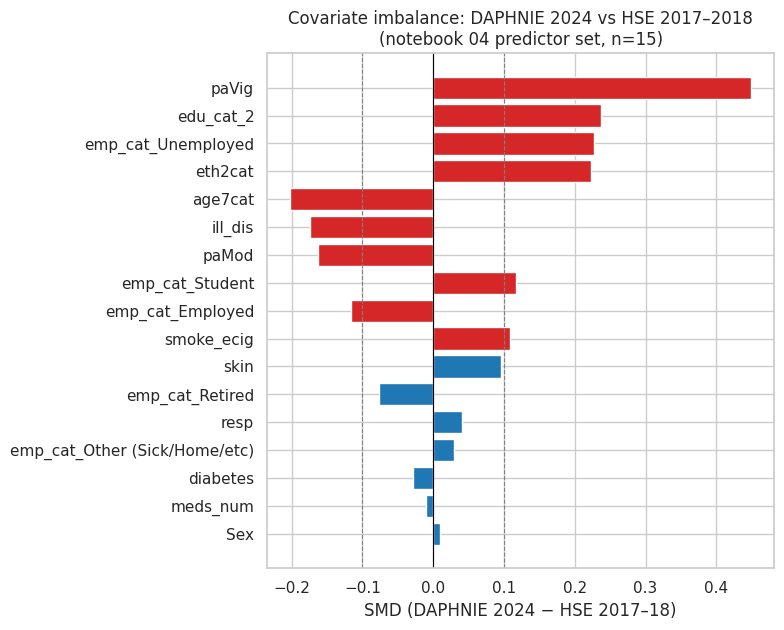

In [23]:
smds_daph_hse1718_plot = smd_daph_hse1718_series.dropna().sort_values(key=abs)
colors = ["#d62728" if abs(v) > 0.1 else "#1f77b4" for v in smds_daph_hse1718_plot]

fig, ax = plt.subplots(figsize=(8, max(5, len(smds_daph_hse1718_plot) * 0.38)))
ax.barh(smds_daph_hse1718_plot.index, smds_daph_hse1718_plot.values, color=colors)
ax.axvline(0,    color="black", linewidth=0.8)
ax.axvline( 0.1, color="grey",  linewidth=0.8, linestyle="--")
ax.axvline(-0.1, color="grey",  linewidth=0.8, linestyle="--")
ax.set_xlabel("SMD (DAPHNIE 2024 − HSE 2017–18)")
ax.set_title("Covariate imbalance: DAPHNIE 2024 vs HSE 2017–2018\n(notebook 04 predictor set, n=15)")
plt.tight_layout()
plt.savefig(PLOTS_PATH / "love_plot_daphnie24_vs_hse1718_all_features.png", dpi=600, bbox_inches="tight")
plt.show()

In [24]:
imbalanced = smd_daph_hse1718_series[smd_daph_hse1718_series.abs() > 0.1].sort_values(key=abs, ascending=False)

print(f"Variables with |SMD| > 0.1: {len(imbalanced)} / {len(smd_daph_hse1718_series.dropna())}")
print()
if len(imbalanced) > 0:
    print("These variables require correction by the density ratio weights in notebook 04:")
    display(imbalanced.round(3).to_frame())

Variables with |SMD| > 0.1: 10 / 17

These variables require correction by the density ratio weights in notebook 04:


,SMD (DAPHNIE 2024 − HSE 2017–18)
paVig,0.449
edu_cat_2,0.237
emp_cat_Unemployed,0.228
eth2cat,0.223
age7cat,-0.202
ill_dis,-0.174
paMod,-0.162
emp_cat_Student,0.118
emp_cat_Employed,-0.116
smoke_ecig,0.109


## Data imbalance with a smaller set of variables

Now we perform the analysis with the baseline features to have a tidier picture.

In [25]:
smds = {
    col: compute_smd(daphnie24[col], src_wt, hse_1718[col], tgt_wt_1)
    for col in BASE_FEATURES
}

smd_series = (
    pd.Series(smds, name="SMD (DAPHNIE 2024 − HSE 2017–18)")
    .sort_values(key=abs, ascending=False)
)

# Weighted means side by side
means = pd.DataFrame({
    "DAPHNIE 2024": {col: weighted_mean(daphnie24[col], src_wt) for col in BASE_FEATURES},
    "HSE 2017–18":  {col: weighted_mean(hse_1718[col],  tgt_wt_1) for col in BASE_FEATURES},
    "SMD":          smds,
}).loc[smd_series.index].round(3)
means["Imbalanced"] = means["SMD"].abs().gt(0.1).map({True: "***", False: ""})

print("Weighted means and SMD (DAPHNIE 2024 − HSE 2017–18):")
display(means)

Weighted means and SMD (DAPHNIE 2024 − HSE 2017–18):


,DAPHNIE 2024,HSE 2017–18,SMD,Imbalanced
edu_cat_2,0.414,0.301,0.237,***
emp_cat_Unemployed,0.080,0.029,0.228,***
eth2cat,0.228,0.142,0.223,***
age7cat,2.656,3.029,-0.202,***
ill_dis,0.348,0.432,-0.174,***
emp_cat_Student,0.072,0.045,0.118,***
emp_cat_Employed,0.529,0.586,-0.116,***
smoke_ecig,0.236,0.191,0.109,***
emp_cat_Retired,0.197,0.228,-0.076,
emp_cat_Other (Sick/Home/etc),0.119,0.110,0.029,


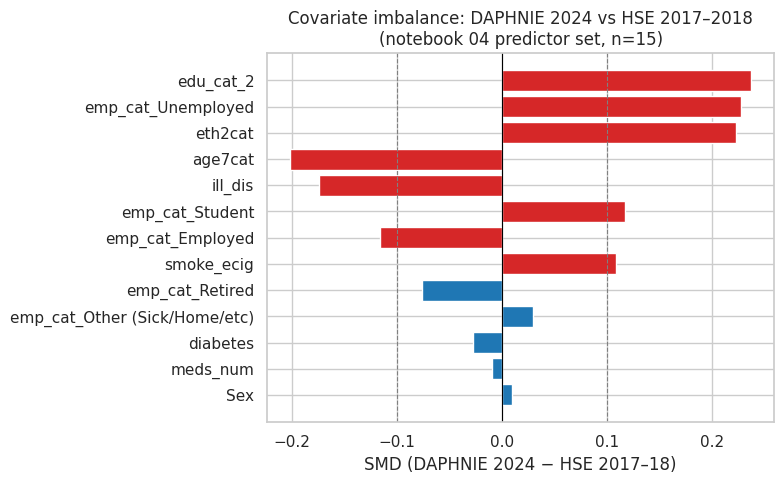

In [26]:
smds_plot = smd_series.dropna().sort_values(key=abs)
colors = ["#d62728" if abs(v) > 0.1 else "#1f77b4" for v in smds_plot]

fig, ax = plt.subplots(figsize=(8, max(5, len(smds_plot) * 0.38)))
ax.barh(smds_plot.index, smds_plot.values, color=colors)
ax.axvline(0,    color="black", linewidth=0.8)
ax.axvline( 0.1, color="grey",  linewidth=0.8, linestyle="--")
ax.axvline(-0.1, color="grey",  linewidth=0.8, linestyle="--")
ax.set_xlabel("SMD (DAPHNIE 2024 − HSE 2017–18)")
ax.set_title("Covariate imbalance: DAPHNIE 2024 vs HSE 2017–2018\n(notebook 04 predictor set, n=15)")
plt.tight_layout()
plt.savefig(PLOTS_PATH / "love_plot_daphnie24_vs_hse1718_base_features.png", dpi=600, bbox_inches="tight")
plt.show()

In [27]:
smds_daph_hse22 = {
    col: compute_smd(daphnie24[col], src_wt, hse_2022[col], tgt_wt_2)
    for col in ALL_FEATURES
}

smd_daph_hse22_series = (
    pd.Series(smds_daph_hse22, name="SMD (DAPHNIE 2024 − HSE 2022)")
    .sort_values(key=abs, ascending=False)
)

# Weighted means side by side
means = pd.DataFrame({
    "DAPHNIE 2024": {col: weighted_mean(daphnie24[col], src_wt) for col in ALL_FEATURES},
    "HSE 2022":  {col: weighted_mean(hse_2022[col],  tgt_wt_2) for col in ALL_FEATURES},
    "SMD":          smds_daph_hse22,
}).loc[smd_daph_hse22_series.index].round(3)
means["Imbalanced"] = means["SMD"].abs().gt(0.1).map({True: "***", False: ""})

print("Weighted means and SMD (DAPHNIE 2024 − HSE 2022):")
display(means)

Weighted means and SMD (DAPHNIE 2024 − HSE 2022):


,DAPHNIE 2024,HSE 2022,SMD,Imbalanced
paVig,1.906,1.580,0.400,***
paMod,2.267,2.578,-0.280,***
emp_cat_Unemployed,0.080,0.020,0.278,***
age7cat,2.656,3.145,-0.260,***
eth2cat,0.228,0.156,0.183,***
ill_dis,0.348,0.418,-0.146,***
emp_cat_Employed,0.529,0.596,-0.135,***
skin,0.030,0.013,0.119,***
emp_cat_Student,0.072,0.047,0.108,***
resp,0.089,0.068,0.077,


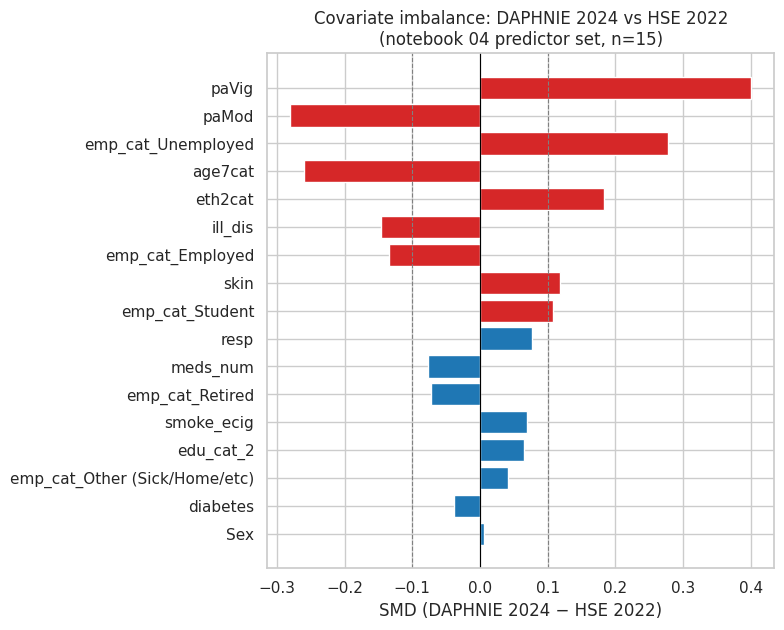

In [28]:
smds_plot = smd_daph_hse22_series.dropna().sort_values(key=abs)
colors = ["#d62728" if abs(v) > 0.1 else "#1f77b4" for v in smds_plot]

fig, ax = plt.subplots(figsize=(8, max(5, len(smds_plot) * 0.38)))
ax.barh(smds_plot.index, smds_plot.values, color=colors)
ax.axvline(0,    color="black", linewidth=0.8)
ax.axvline( 0.1, color="grey",  linewidth=0.8, linestyle="--")
ax.axvline(-0.1, color="grey",  linewidth=0.8, linestyle="--")
ax.set_xlabel("SMD (DAPHNIE 2024 − HSE 2022)")
ax.set_title("Covariate imbalance: DAPHNIE 2024 vs HSE 2022\n(notebook 04 predictor set, n=15)")
plt.tight_layout()
plt.savefig(PLOTS_PATH / "love_plot_daphnie24_vs_hse2022_all_features.png", dpi=600, bbox_inches="tight")
plt.show()

In [29]:
smds_daph_hse22 = {
    col: compute_smd(daphnie24[col], src_wt, hse_2022[col], tgt_wt_2)
    for col in BASE_FEATURES
}

smd_daph_hse22_series = (
    pd.Series(smds_daph_hse22, name="SMD (DAPHNIE 2024 − HSE 2022)")
    .sort_values(key=abs, ascending=False)
)

# Weighted means side by side
means = pd.DataFrame({
    "DAPHNIE 2024": {col: weighted_mean(daphnie24[col], src_wt) for col in BASE_FEATURES},
    "HSE 2022":  {col: weighted_mean(hse_2022[col],  tgt_wt_2) for col in BASE_FEATURES},
    "SMD":          smds_daph_hse22,
}).loc[smd_daph_hse22_series.index].round(3)
means["Imbalanced"] = means["SMD"].abs().gt(0.1).map({True: "***", False: ""})

print("Weighted means and SMD (DAPHNIE 2024 − HSE 2022):")
display(means)

Weighted means and SMD (DAPHNIE 2024 − HSE 2022):


,DAPHNIE 2024,HSE 2022,SMD,Imbalanced
emp_cat_Unemployed,0.080,0.020,0.278,***
age7cat,2.656,3.145,-0.260,***
eth2cat,0.228,0.156,0.183,***
ill_dis,0.348,0.418,-0.146,***
emp_cat_Employed,0.529,0.596,-0.135,***
emp_cat_Student,0.072,0.047,0.108,***
meds_num,1.216,1.313,-0.077,
emp_cat_Retired,0.197,0.226,-0.072,
smoke_ecig,0.236,0.206,0.070,
edu_cat_2,0.414,0.383,0.065,


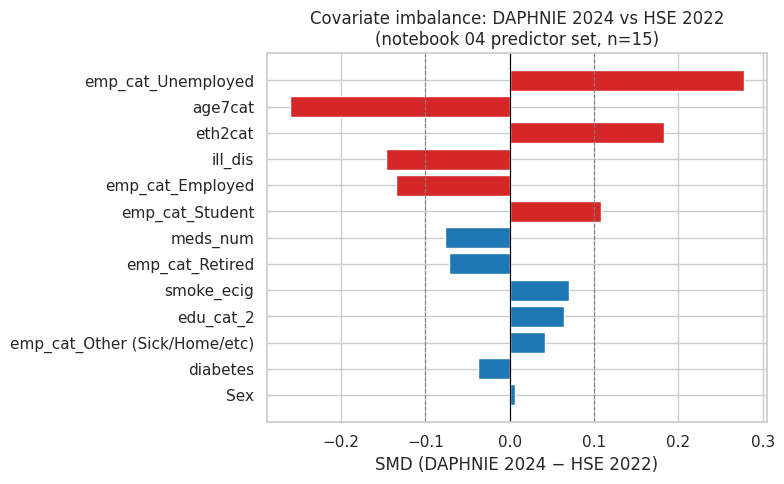

In [30]:
smds_plot = smd_daph_hse22_series.dropna().sort_values(key=abs)
colors = ["#d62728" if abs(v) > 0.1 else "#1f77b4" for v in smds_plot]

fig, ax = plt.subplots(figsize=(8, max(5, len(smds_plot) * 0.38)))
ax.barh(smds_plot.index, smds_plot.values, color=colors)
ax.axvline(0,    color="black", linewidth=0.8)
ax.axvline( 0.1, color="grey",  linewidth=0.8, linestyle="--")
ax.axvline(-0.1, color="grey",  linewidth=0.8, linestyle="--")
ax.set_xlabel("SMD (DAPHNIE 2024 − HSE 2022)")
ax.set_title("Covariate imbalance: DAPHNIE 2024 vs HSE 2022\n(notebook 04 predictor set, n=15)")
plt.tight_layout()
plt.savefig(PLOTS_PATH / "love_plot_daphnie24_vs_hse2022_base_features.png", dpi=600, bbox_inches="tight")
plt.show()